In [1]:
import pandas as pd
from collections import defaultdict

# Load match data
df = pd.read_csv('atp_matches_2023.csv')
df = df.sort_values('tourney_date')

# Initialize Elo ratings
elo_ratings = defaultdict(lambda: 1500)

# Store Elo snapshot *before* each match
elo_snapshots = []

K = 30

def win_prob(rating_i, rating_j):
    return 1 / (1 + 10 ** ((rating_j - rating_i) / 400))

for _, match in df.iterrows():
    winner = match['winner_name']
    loser = match['loser_name']

    rating_winner = elo_ratings[winner]
    rating_loser = elo_ratings[loser]

    # Record pre-match Elo ratings
    elo_snapshots.append({
        'date': match['tourney_date'],
        'tournament': match['tourney_name'],
        'winner': winner,
        'loser': loser,
        'winner_elo_before': rating_winner,
        'loser_elo_before': rating_loser
    })

    # Calculate expected outcomes
    expected_win = win_prob(rating_winner, rating_loser)
    expected_loss = 1 - expected_win

    # Update ratings
    elo_ratings[winner] += K * (1 - expected_win)
    elo_ratings[loser] += K * (0 - expected_loss)

# Create DataFrame
elo_df = pd.DataFrame(elo_snapshots)
elo_df

,date,tournament,winner,loser,winner_elo_before,loser_elo_before
0,20230102,United Cup,Taylor Fritz,Matteo Berrettini,1500.000000,1500.000000
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000
2,20230102,Adelaide 1,Marcos Giron,Richard Gasquet,1500.000000,1500.000000
3,20230102,Adelaide 1,Mackenzie Mcdonald,Daniel Elahi Galan,1500.000000,1500.000000
4,20230102,Adelaide 1,Yoshihito Nishioka,Holger Rune,1500.000000,1500.000000
...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274
2982,20231127,NextGen Finals,Hamad Medjedovic,Abedallah Shelbayh,1570.877850,1447.949709
2983,20231127,NextGen Finals,Abedallah Shelbayh,Alex Michelsen,1438.046036,1489.435844
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672


In [2]:

elo_df['difference'] = elo_df['winner_elo_before'] - elo_df['loser_elo_before']
elo_df

,date,tournament,winner,loser,winner_elo_before,loser_elo_before,difference
0,20230102,United Cup,Taylor Fritz,Matteo Berrettini,1500.000000,1500.000000,0.000000
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,0.000000
2,20230102,Adelaide 1,Marcos Giron,Richard Gasquet,1500.000000,1500.000000,0.000000
3,20230102,Adelaide 1,Mackenzie Mcdonald,Daniel Elahi Galan,1500.000000,1500.000000,0.000000
4,20230102,Adelaide 1,Yoshihito Nishioka,Holger Rune,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,83.006596
2982,20231127,NextGen Finals,Hamad Medjedovic,Abedallah Shelbayh,1570.877850,1447.949709,122.928140
2983,20231127,NextGen Finals,Abedallah Shelbayh,Alex Michelsen,1438.046036,1489.435844,-51.389809
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,9.656621


In [3]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Randomly assign winner to be Player A or B
winner_is_A = np.random.randint(0, 2, size=len(elo_df)) == 1

# Create transformed DataFrame
elo_transformed = pd.DataFrame({
    'date': elo_df['date'],
    'tournament': elo_df['tournament'],
    
    'player_A_name': np.where(winner_is_A, elo_df['winner'], elo_df['loser']),
    'player_B_name': np.where(winner_is_A, elo_df['loser'], elo_df['winner']),
    
    'player_A_elo_before': np.where(winner_is_A, elo_df['winner_elo_before'], elo_df['loser_elo_before']),
    'player_B_elo_before': np.where(winner_is_A, elo_df['loser_elo_before'], elo_df['winner_elo_before']),
    
    'player_A_win': winner_is_A.astype(int)
})
elo_transformed

,date,tournament,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win
0,20230102,United Cup,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1
2,20230102,Adelaide 1,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0
3,20230102,Adelaide 1,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0
4,20230102,Adelaide 1,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0
...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1
2982,20231127,NextGen Finals,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0
2983,20231127,NextGen Finals,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1


In [4]:
elo_transformed['elo_difference'] = elo_transformed['player_A_elo_before'] - elo_transformed ['player_B_elo_before']
elo_transformed

,date,tournament,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference
0,20230102,United Cup,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0,0.000000
1,20230102,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1,0.000000
2,20230102,Adelaide 1,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0,0.000000
3,20230102,Adelaide 1,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0,0.000000
4,20230102,Adelaide 1,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0,0.000000
...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1,83.006596
2982,20231127,NextGen Finals,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0,-122.928140
2983,20231127,NextGen Finals,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0,51.389809
2984,20231127,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1,9.656621


In [5]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

by .GlobalEnv when processing object ‘.pbd_env’


In [6]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [7]:
%%R

require('tidyverse')
require('DescTools')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: DescTools


In [8]:
%%R -i elo_transformed

logistic <- glm(player_A_win ~ player_A_elo_before + player_B_elo_before, data=elo_transformed, family="binomial")

print(summary(logistic))
print(PseudoR2(logistic, which="McFadden"))


Call:
glm(formula = player_A_win ~ player_A_elo_before + player_B_elo_before, 
    family = "binomial", data = elo_transformed)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.2856040  0.9576370  -0.298    0.766    
player_A_elo_before  0.0066359  0.0005647  11.752   <2e-16 ***
player_B_elo_before -0.0064649  0.0005580 -11.585   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4139.0  on 2985  degrees of freedom
Residual deviance: 3905.7  on 2983  degrees of freedom
AIC: 3911.7

Number of Fisher Scoring iterations: 4

  McFadden 
0.05636227 


In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
clf = LogisticRegression(C=1e9, solver='lbfgs', max_iter=4000)

In [11]:
df = elo_transformed.sample(len(elo_transformed), random_state=1) 

# Fit the data to the model
X = df[['elo_difference']]
y = df['player_A_win']

clf.fit(X, y)

LogisticRegression(C=1000000000.0, max_iter=4000)

In [12]:
clf.predict(X)

array([0, 1, 1, ..., 1, 1, 0], shape=(2986,))

In [13]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, \
                            accuracy_score, f1_score

In [14]:
matrix = confusion_matrix(y, clf.predict(X))
pd.DataFrame(matrix, 
             columns = ['pred_lost', 'pred_won'], 
             index=['lost', 'won'])\
    .assign(Total=lambda x: x.sum(axis=1))\
    .sort_values(by='Total')[['pred_lost', 'pred_won', 'Total']]\
    .T.assign(Total = lambda x: x.sum(axis=1)).T

,pred_lost,pred_won,Total
won,653,821,1474
lost,980,532,1512
Total,1633,1353,2986


In [15]:
accuracy_score(clf.predict(X), y)

0.6031480241125251

In [16]:
recall_score(y, clf.predict(X))

0.5569877883310719

In [17]:
precision_score(y, clf.predict(X))

0.60679970436068

In [18]:
clf.classes_

array([0, 1])

In [19]:
clf.predict_proba(X)

array([[0.69982189, 0.30017811],
       [0.25838409, 0.74161591],
       [0.34066839, 0.65933161],
       ...,
       [0.44592228, 0.55407772],
       [0.39662695, 0.60337305],
       [0.62099053, 0.37900947]], shape=(2986, 2))

In [20]:
elo_transformed['predicted_prob_py'] = clf.predict_proba(X)[:, 1]
elo_transformed['prediction_py'] = clf.predict(X)

In [21]:
elo_transformed.sort_values('elo_difference')

,date,tournament,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,predicted_prob_py,prediction_py
2085,20230807,Canada Masters,Ben Shelton,Carlos Alcaraz,1410.848961,1864.117346,0,-453.268385,0.404691,0
2147,20230814,Cincinnati Masters,Max Purcell,Carlos Alcaraz,1432.599522,1846.423679,0,-413.824157,0.494024,0
2346,20230828,Us Open,Bernabe Zapata Miralles,Novak Djokovic,1458.760979,1857.668601,0,-398.907621,0.568678,1
2359,20230828,Us Open,Lloyd Harris,Carlos Alcaraz,1464.366432,1852.334845,0,-387.968413,0.494024,0
2365,20230828,Us Open,Alexandre Muller,Novak Djokovic,1481.946315,1860.411504,0,-378.465190,0.394523,0
...,...,...,...,...,...,...,...,...,...,...
2347,20230828,Us Open,Carlos Alcaraz,Daniel Evans,1848.794448,1499.381908,1,349.412541,0.445203,0
1705,20230703,Wimbledon,Carlos Alcaraz,Matteo Berrettini,1846.751562,1495.784060,1,350.967502,0.614379,1
2565,20230927,Beijing,Alexander Zverev,Diego Schwartzman,1771.926817,1415.766524,1,356.160293,0.241616,0
1803,20230703,Wimbledon,Carlos Alcaraz,Jeremy Chardy,1854.290733,1467.385701,1,386.905031,0.607626,1


## Ground Truth


Attaching package: ‘flexplot’

The following object is masked from ‘package:ggplot2’:

    flip_data



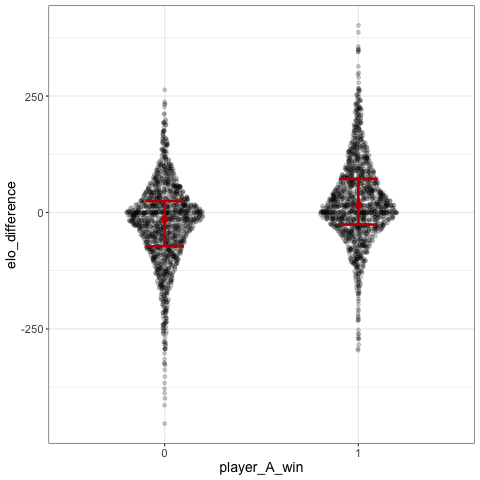

In [22]:
%%R -i elo_transformed

library(flexplot)
flexplot(elo_difference ~ player_A_win, data=elo_transformed)

## Look at differences in python model output

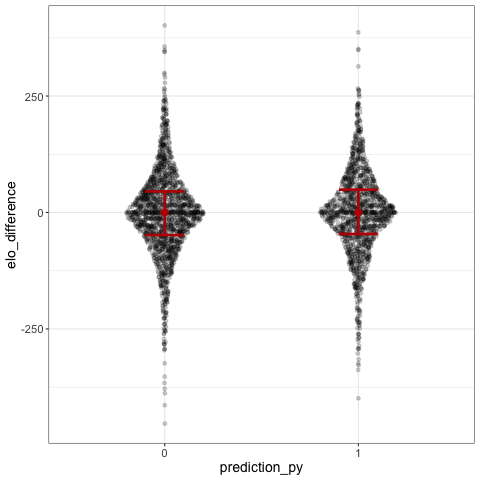

In [23]:
%%R

library(flexplot)

flexplot(elo_difference ~ prediction_py, data=elo_transformed)

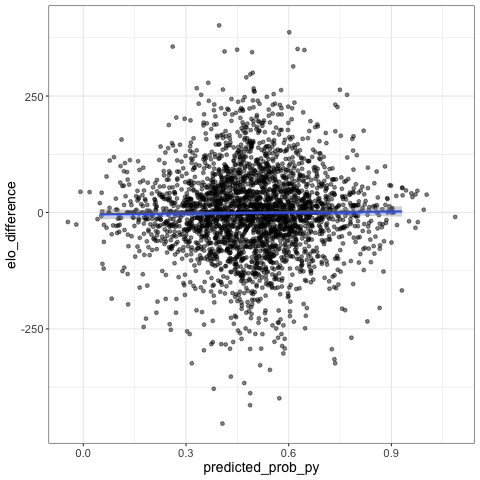

In [24]:
%%R -i elo_transformed

library(flexplot)

flexplot(elo_difference ~ predicted_prob_py, data=elo_transformed, method='lm')

## now do it in R

In [25]:
%%R 

logistic <- glm(player_A_win ~ elo_difference, data=elo_transformed, family=binomial)
print(summary(logistic))
print(PseudoR2(logistic, which="McFadden"))



Call:
glm(formula = player_A_win ~ elo_difference, family = binomial, 
    data = elo_transformed)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.0239034  0.0380422  -0.628     0.53    
elo_difference  0.0065491  0.0004661  14.050   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4139.0  on 2985  degrees of freedom
Residual deviance: 3905.8  on 2984  degrees of freedom
AIC: 3909.8

Number of Fisher Scoring iterations: 4

  McFadden 
0.05634419 


In [26]:
%%R 

df <- elo_transformed %>% mutate(
    predict_proba_R = predict(logistic, type="response"),
    predict_R = ifelse(predict_proba_R > .5, 1,0)
) %>% arrange(elo_difference)

df %>% head()

         date         tournament           player_A_name  player_B_name
2085 20230807     Canada Masters             Ben Shelton Carlos Alcaraz
2147 20230814 Cincinnati Masters             Max Purcell Carlos Alcaraz
2346 20230828            Us Open Bernabe Zapata Miralles Novak Djokovic
2359 20230828            Us Open            Lloyd Harris Carlos Alcaraz
2365 20230828            Us Open        Alexandre Muller Novak Djokovic
2325 20230828            Us Open             Ben Shelton Novak Djokovic
     player_A_elo_before player_B_elo_before player_A_win elo_difference
2085            1410.849            1864.117            0      -453.2684
2147            1432.600            1846.424            0      -413.8242
2346            1458.761            1857.669            0      -398.9076
2359            1464.366            1852.335            0      -387.9684
2365            1481.946            1860.412            0      -378.4652
2325            1476.306            1842.450            0 

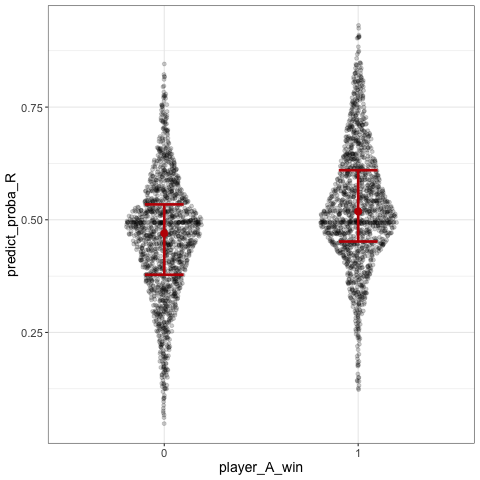

In [27]:
%%R 

flexplot(predict_proba_R ~ player_A_win, data=df, method='lm')

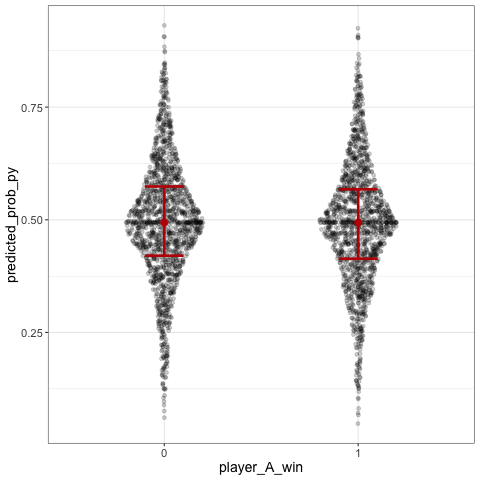

In [28]:
%%R 

flexplot(predicted_prob_py ~ player_A_win, data=df, method='lm')

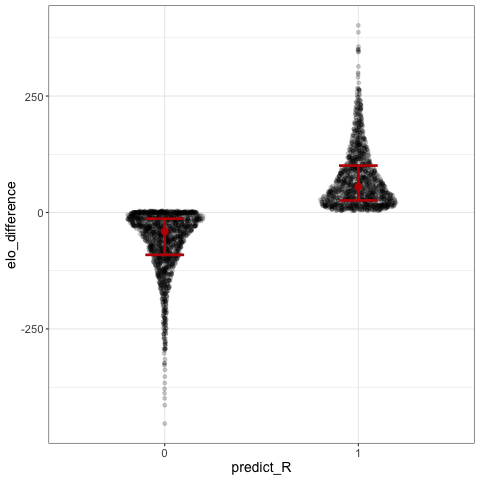

In [34]:
%%R 

flexplot(elo_difference ~ predict_R, data=df)
# flexplot(elo_difference ~ prediction_py, data=df)

In [30]:
%%R 

# Create confusion matrix
conf_mat <- table(df$predict_R, df$player_A_win)
print(conf_mat) 

# Extract TP, FP, FN
TP <- conf_mat[2,2]
FP <- conf_mat[2,1]
FN <- conf_mat[1,2]
# Calculate Precision and Recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
# Print
cat("Precision:", precision, "\n")
cat("Recall:", recall, "\n")

   
      0   1
  0 980 653
  1 532 821
Precision: 0.6067997 
Recall: 0.5569878 


### Trying surface-level elo 

In [31]:
import pandas as pd
from collections import defaultdict

# Load and sort match data
df = pd.read_csv('atp_matches_2023.csv')
df = df.sort_values('tourney_date')

# Separate Elo ratings per surface (e.g., 'Hard', 'Clay', 'Grass')
surface_elo_ratings = defaultdict(lambda: defaultdict(lambda: 1500))

# Store surface-specific Elo snapshots
surface_elo_snapshots = []

K = 30

def win_prob(rating_i, rating_j):
    return 1 / (1 + 10 ** ((rating_j - rating_i) / 400))

for _, match in df.iterrows():
    winner = match['winner_name']
    loser = match['loser_name']
    surface = match['surface']  # Make sure your CSV has this column

    rating_winner = surface_elo_ratings[surface][winner]
    rating_loser = surface_elo_ratings[surface][loser]

    # Record pre-match Elo ratings
    surface_elo_snapshots.append({
        'date': match['tourney_date'],
        'tournament': match['tourney_name'],
        'surface': surface,
        'winner': winner,
        'loser': loser,
        'winner_elo_before': rating_winner,
        'loser_elo_before': rating_loser
    })

    # Expected result
    expected_win = win_prob(rating_winner, rating_loser)
    expected_loss = 1 - expected_win

    # Update surface-specific ratings
    surface_elo_ratings[surface][winner] += K * (1 - expected_win)
    surface_elo_ratings[surface][loser] += K * (0 - expected_loss)

# Build final DataFrame
elo_surface_df = pd.DataFrame(surface_elo_snapshots)
elo_surface_df

,date,tournament,surface,winner,loser,winner_elo_before,loser_elo_before
0,20230102,United Cup,Hard,Taylor Fritz,Matteo Berrettini,1500.000000,1500.000000
1,20230102,Adelaide 1,Hard,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000
2,20230102,Adelaide 1,Hard,Marcos Giron,Richard Gasquet,1500.000000,1500.000000
3,20230102,Adelaide 1,Hard,Mackenzie Mcdonald,Daniel Elahi Galan,1500.000000,1500.000000
4,20230102,Adelaide 1,Hard,Yoshihito Nishioka,Holger Rune,1500.000000,1500.000000
...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,Hamad Medjedovic,Luca Van Assche,1570.098888,1457.293447
2982,20231127,NextGen Finals,Hard,Hamad Medjedovic,Abedallah Shelbayh,1580.392899,1488.744462
2983,20231127,NextGen Finals,Hard,Abedallah Shelbayh,Alex Michelsen,1477.611953,1465.029038
2984,20231127,NextGen Finals,Hard,Luca Van Assche,Abedallah Shelbayh,1446.999436,1492.068942


In [32]:
import numpy as np

# Randomly assign winner to be Player A or B
winner_is_A = np.random.randint(0, 2, size=len(elo_surface_df)) == 1

# Create transformed DataFrame
elo_transformed_new = pd.DataFrame({
    'date': elo_surface_df['date'],
    'tournament': elo_surface_df['tournament'],
    'surface': elo_surface_df['surface'],
    
    'player_A_name': np.where(winner_is_A, elo_surface_df['winner'], elo_surface_df['loser']),
    'player_B_name': np.where(winner_is_A, elo_surface_df['loser'], elo_surface_df['winner']),
    
    'player_A_elo_before': np.where(winner_is_A, elo_surface_df['winner_elo_before'], elo_surface_df['loser_elo_before']),
    'player_B_elo_before': np.where(winner_is_A, elo_surface_df['loser_elo_before'], elo_surface_df['winner_elo_before']),
    
    'player_A_win': winner_is_A.astype(int)
})
elo_transformed_new

,date,tournament,surface,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win
0,20230102,United Cup,Hard,Taylor Fritz,Matteo Berrettini,1500.000000,1500.000000,1
1,20230102,Adelaide 1,Hard,Felix Auger Aliassime,Alexei Popyrin,1500.000000,1500.000000,0
2,20230102,Adelaide 1,Hard,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0
3,20230102,Adelaide 1,Hard,Mackenzie Mcdonald,Daniel Elahi Galan,1500.000000,1500.000000,1
4,20230102,Adelaide 1,Hard,Yoshihito Nishioka,Holger Rune,1500.000000,1500.000000,1
...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,Hamad Medjedovic,Luca Van Assche,1570.098888,1457.293447,1
2982,20231127,NextGen Finals,Hard,Abedallah Shelbayh,Hamad Medjedovic,1488.744462,1580.392899,0
2983,20231127,NextGen Finals,Hard,Alex Michelsen,Abedallah Shelbayh,1465.029038,1477.611953,0
2984,20231127,NextGen Finals,Hard,Abedallah Shelbayh,Luca Van Assche,1492.068942,1446.999436,0
